<a href="https://colab.research.google.com/github/asiddiqha/ai-workbench/blob/main/Naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('naive bayes algm.csv')

In [15]:
# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 60)
print("Dataset Information")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("Summary Statistics")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)
display(df.isnull().sum().to_frame(name="Missing Values"))

print("\n" + "=" * 60)
print("Duplicate Records")
print("=" * 60)
print(f"Number of Duplicate Rows : {df.duplicated().sum()}")

Dataset Shape
Rows    : 30
Columns : 6

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Email_Text            30 non-null     object
 1   Contains_Link         30 non-null     object
 2   Contains_Offer        30 non-null     object
 3   Contains_Money_Words  30 non-null     object
 4   Email_Length          30 non-null     object
 5   Spam                  30 non-null     object
dtypes: object(6)
memory usage: 1.5+ KB

Summary Statistics


,Email_Text,Contains_Link,Contains_Offer,Contains_Money_Words,Email_Length,Spam
count,30,30,30,30,30,30
unique,30,2,2,2,2,2
top,Congratulations! You have won a free iPhone. C...,Yes,No,No,Short,Spam
freq,1,15,17,18,19,15



Missing Values


,Missing Values
Email_Text,0
Contains_Link,0
Contains_Offer,0
Contains_Money_Words,0
Email_Length,0
Spam,0



Duplicate Records
Number of Duplicate Rows : 0


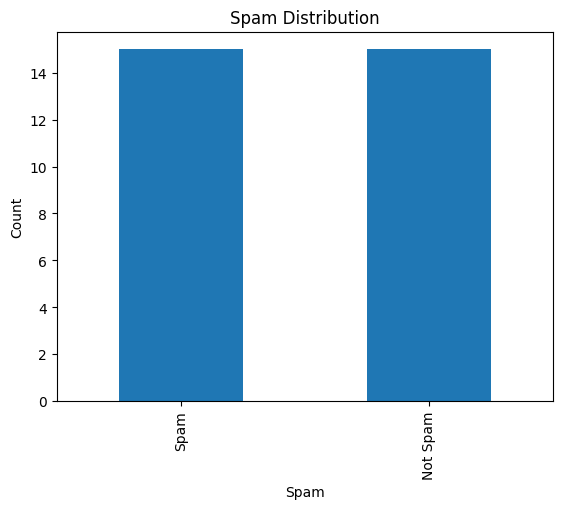

In [17]:
df['Spam'].value_counts().plot(kind='bar')
plt.title("Spam Distribution")
plt.xlabel("Spam")
plt.ylabel("Count")
plt.show()

In [18]:
# Setting Seaborn theme for plots
sns.set_theme(style="whitegrid", palette="Set2")

# Improve default figure resolution
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

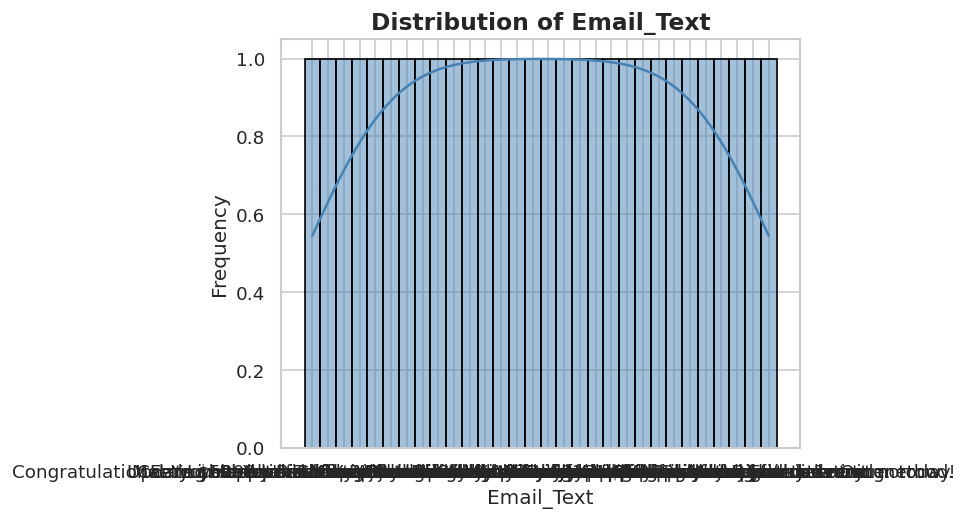

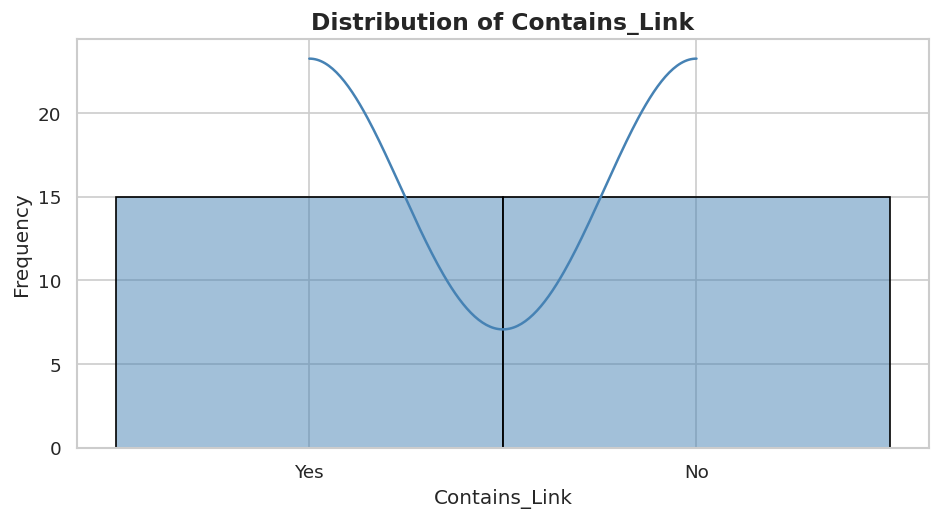

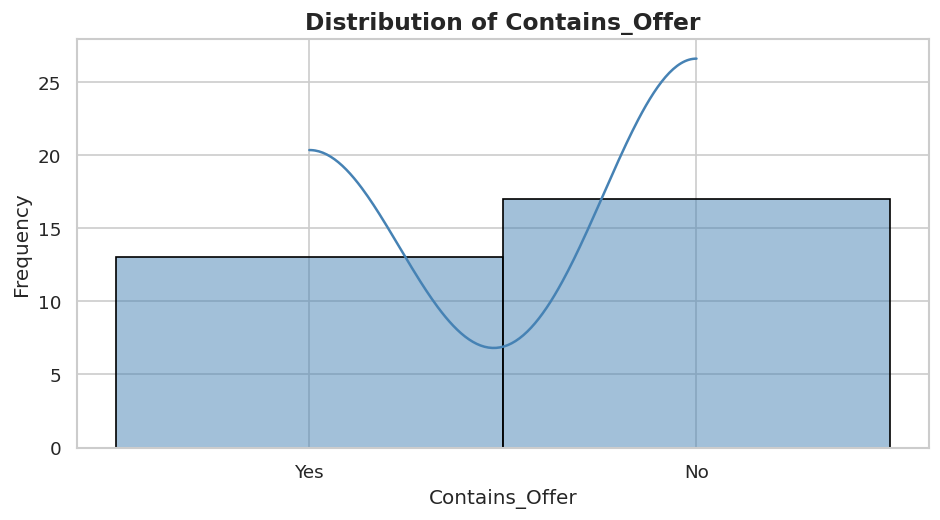

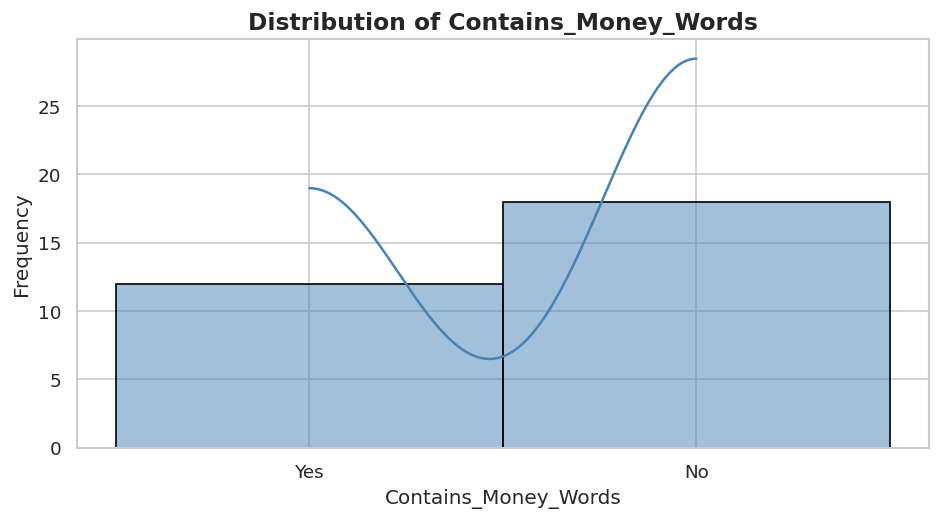

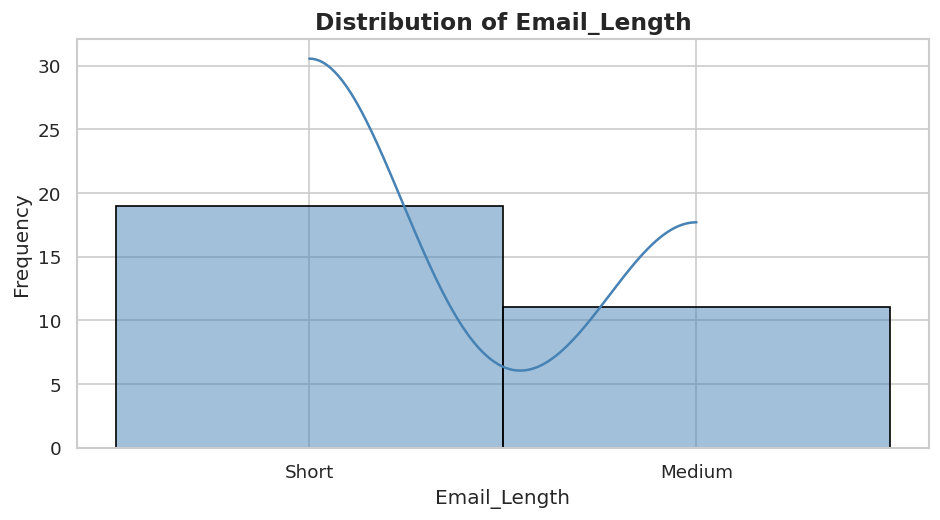

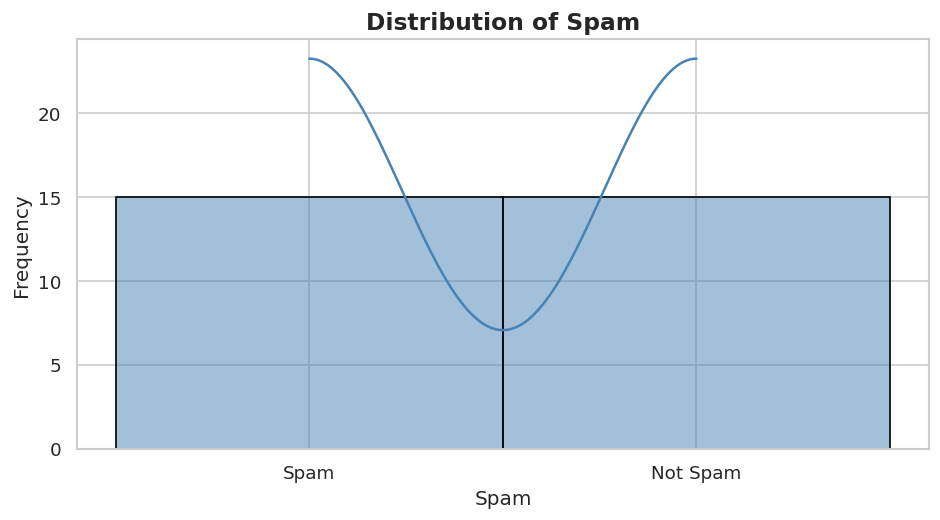

In [22]:
# ==========================================================
# Distribution of Categorical Features
# ==========================================================
# Purpose:
# Visualize the frequency of each category.
# Helps understand class balance and category distribution.
# ==========================================================

# Select all categorical columns
numeric_cols = df.select_dtypes(include="object").columns

# Plot histogram for each numerical feature
for col in numeric_cols:

    plt.figure(figsize=(8,4.5))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True,
        color="steelblue",
        edgecolor="black"
    )

    plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [24]:
df.columns

Index(['Email_Text', 'Contains_Link', 'Contains_Offer', 'Contains_Money_Words',
       'Email_Length', 'Spam'],
      dtype='object')

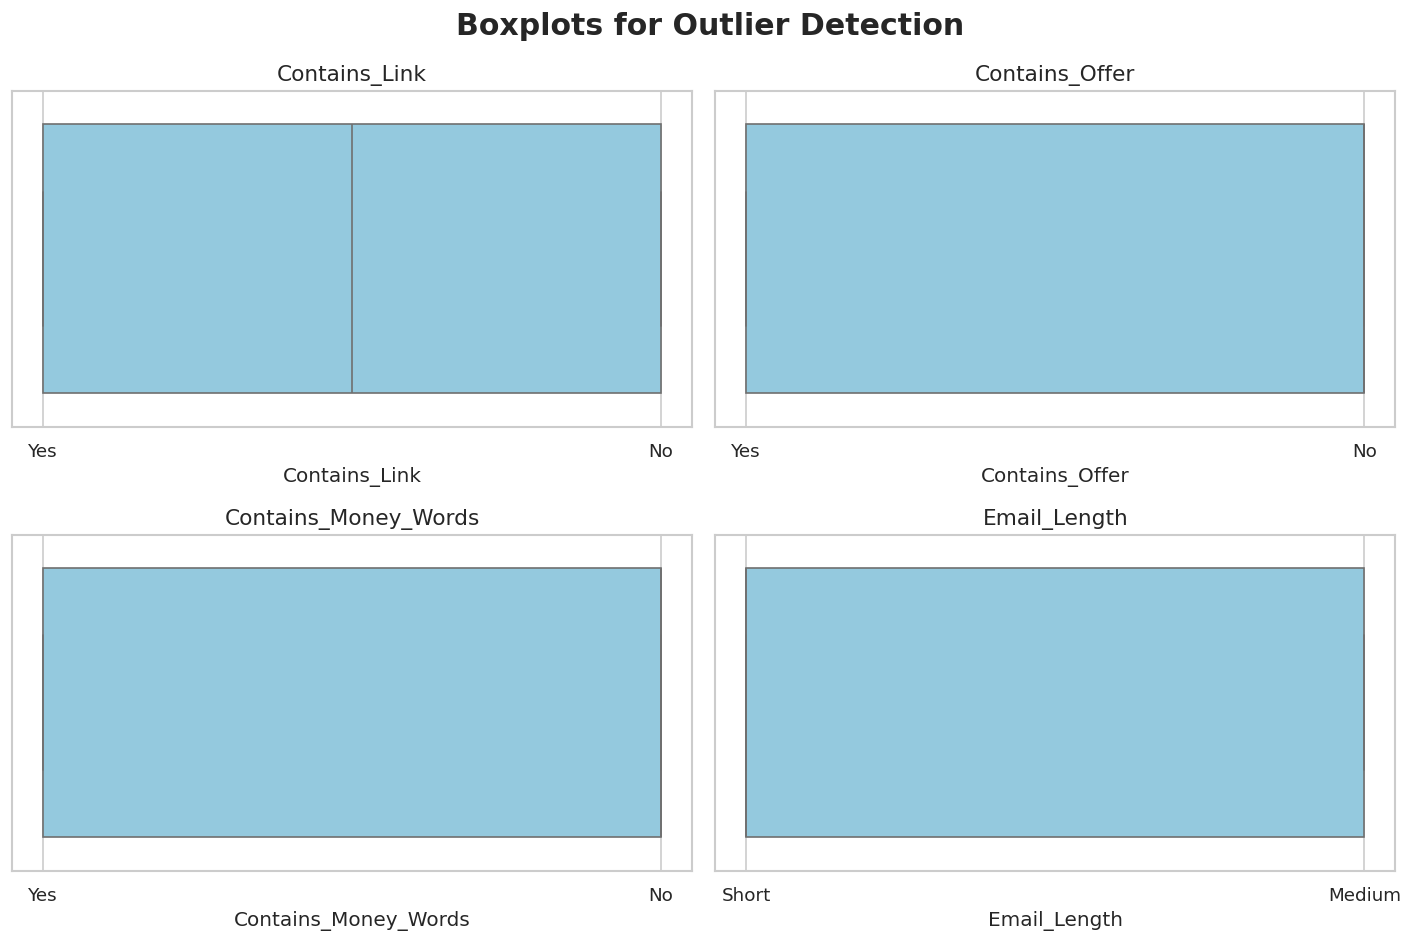

In [26]:
# ==========================================================
# Outlier Detection using Boxplots
# ==========================================================
# Purpose:
# Detect unusually high or low values that may affect
# model performance.
# ==========================================================

outlier_columns = [
    "Contains_Link",
    "Contains_Offer",
    "Contains_Money_Words",
    "Email_Length"
]

fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, column in zip(axes.flatten(), outlier_columns):

    sns.boxplot(
        x=df[column],
        ax=ax,
        color="skyblue"
    )

    ax.set_title(column, fontsize=13)

plt.suptitle(
    "Boxplots for Outlier Detection",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

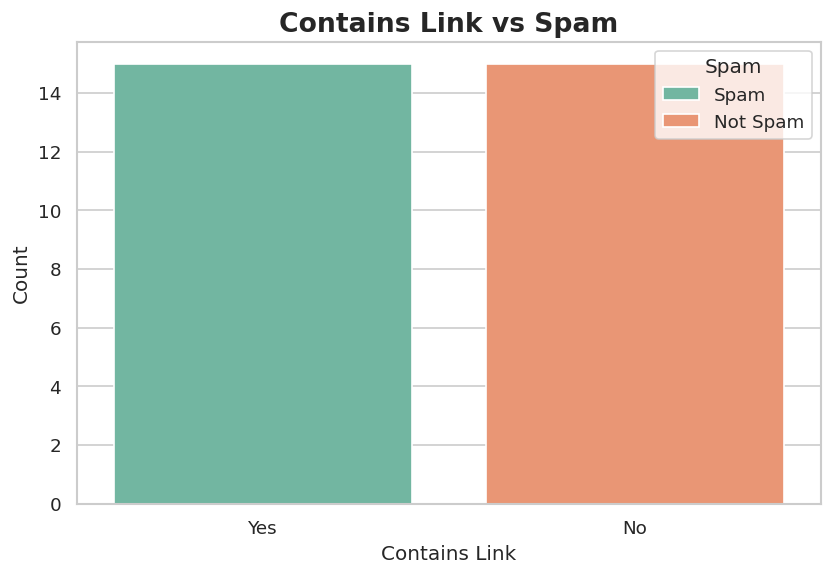

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contains_Link",
    hue="Spam"
)

plt.title(
    "Contains Link vs Spam",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contains Link")
plt.ylabel("Count")

plt.legend(title="Spam")

plt.show()

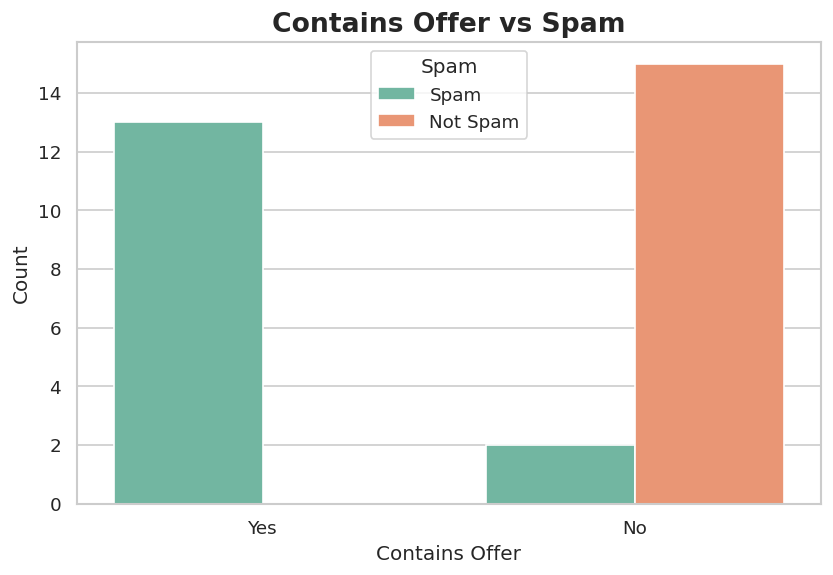

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contains_Offer",
    hue="Spam"
)

plt.title(
    "Contains Offer vs Spam",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contains Offer")
plt.ylabel("Count")

plt.legend(title="Spam")

plt.show()

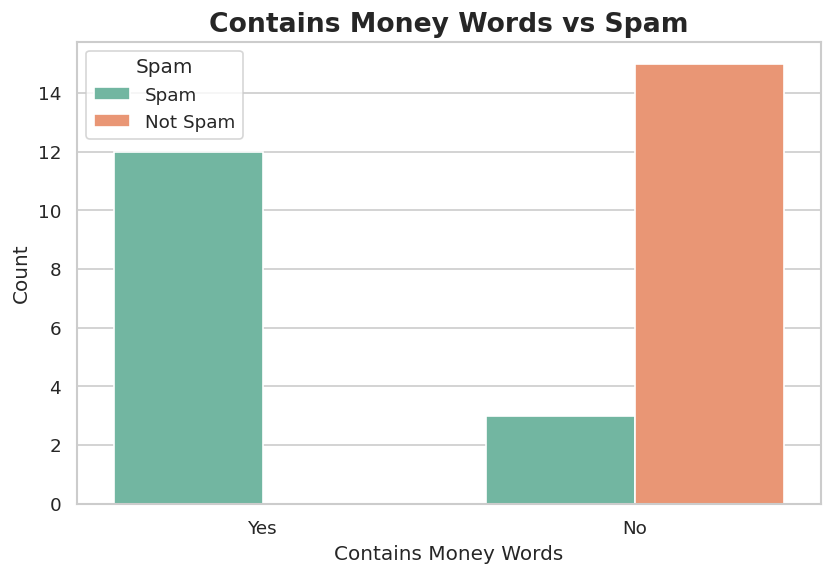

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contains_Money_Words",
    hue="Spam"
)

plt.title(
    "Contains Money Words vs Spam",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contains Money Words")
plt.ylabel("Count")

plt.legend(title="Spam")

plt.show()

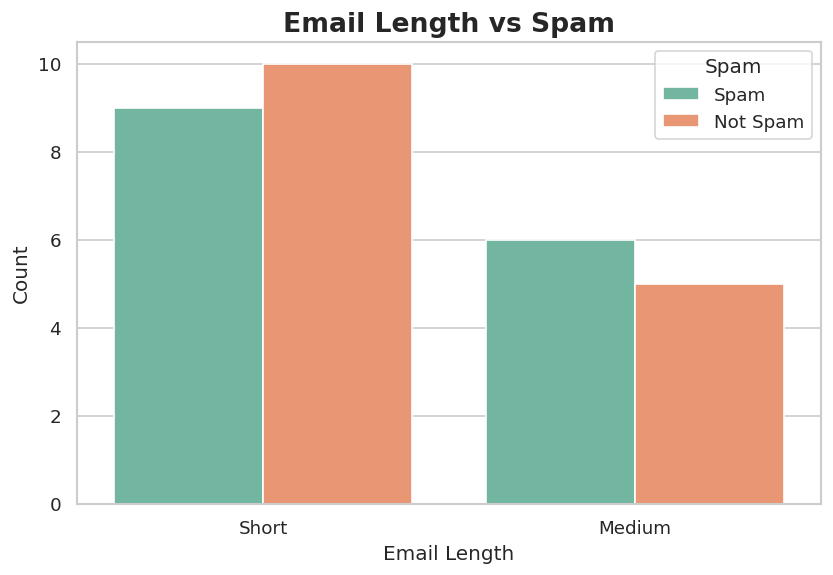

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Email_Length",
    hue="Spam"
)

plt.title(
    "Email Length vs Spam",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Email Length")
plt.ylabel("Count")

plt.legend(title="Spam")

plt.show()

In [31]:
# ==========================================================
# Label Encoding
# ==========================================================
# Purpose:
# Convert all categorical (object) columns into numerical values
# required by machine learning algorithms.
# ==========================================================

# Create LabelEncoder object
le = LabelEncoder()

# Select all categorical columns
categorical_cols = df.select_dtypes(include="object").columns

# Apply Label Encoding
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Label Encoding Completed Successfully!")

Label Encoding Completed Successfully!


In [32]:
X = df.drop('Spam', axis=1)
y = df['Spam']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
model = CategoricalNB()
model.fit(X_train, y_train)
pred = model.predict(X_test)
accuracy_score(y_test, pred)

# Print Accuracy
print("Categorical Naive Bayes Accuracy:",
accuracy_score(y_test, pred))
# Print Confusion Matrix
print(confusion_matrix(y_test, pred))
# Print Classification Report
print(classification_report(y_test, pred))

Categorical Naive Bayes Accuracy: 1.0
[[4 0]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

